# Kalix speed results — team dashboard

Plots the long-term performance database (`speed_results.csv`) written by
`run_speed_tests.py`. Everyone sees the same thing: **all machines, all
histories**. Tests and machines are discovered from the database — nothing
here is hardcoded.

**How to read it**
- **Colour = machine**, everywhere (each machine keeps the palette slot it got
  on first appearance in the database). Tests are identified by panel.
- Machines share panels but never a line: absolute times are only comparable
  within one machine. The drift chart indexes each machine to **its own**
  latest measurement, so line *shapes* are comparable across machines even
  though speeds are not.
- The x-axis is the **benchmark run** (ordinal, ordered by commit date): real
  calendar spacing between runs is information-free. Ticks show commit sha
  (* = dirty tree), kalix version, and commit date.
- The comparator is always the **min** of repeated runs. Hollow markers =
  dirty working tree.

Re-run all cells after adding new results.

In [1]:
import math
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("speed_results.csv", parse_dates=["test_date"])
df["commit_date"] = pd.to_datetime(df["commit_date"], utc=True, format="ISO8601")
df = df.sort_values(["commit_date", "test_date"])

# Discovered from the database; order of first appearance (append-only, so
# stable forever - new tests/machines never repaint existing ones).
TESTS = list(df.drop_duplicates("test_name")["test_name"])
MACHINES = list(df.drop_duplicates("hostname")["hostname"])

# Colour follows the MACHINE, everywhere.
PALETTE = ["#2a78d6", "#1baf7a", "#eda100", "#008300",
           "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
if len(MACHINES) > len(PALETTE):
    print(f"WARNING: {len(MACHINES)} machines but {len(PALETTE)} palette slots.")
MACHINE_COLOURS = {m: PALETTE[i % len(PALETTE)] for i, m in enumerate(MACHINES)}

SURFACE, INK, INK_2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e8e8e6"

def short_host(h):
    """First segment of the hostname, for labels/legends."""
    return h.split(".")[0]

def style_axes(ax, title=None):
    """House style: recessive grid and axes, text in ink tokens."""
    ax.set_facecolor(SURFACE)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=INK_2, labelsize=9)
    if title:
        ax.set_title(title, loc="left", fontsize=11, color=INK)

# Ordinal benchmark-run axis: one position per suite invocation, ordered by
# commit_date (then test_date, so same-commit re-runs keep their own positions).
runs = (df[["commit_date", "test_date", "commit_sha", "commit_dirty", "kalix_version"]]
        .drop_duplicates(subset=["commit_date", "test_date"])
        .sort_values(["commit_date", "test_date"])
        .reset_index(drop=True))
runs["run_id"] = runs.index + 1
runs["run_label"] = runs.apply(
    lambda r: f"{r.commit_sha}{'*' if r.commit_dirty else ''}\n"
              f"v{r.kalix_version}\n{r.commit_date:%d %b %y}", axis=1)
df = df.merge(runs[["commit_date", "test_date", "run_id"]],
              on=["commit_date", "test_date"])

def apply_run_axis(ax, max_ticks=8):
    """Benchmark-run ticks with sha/version/date labels, auto-thinned."""
    step = max(1, math.ceil(len(runs) / max_ticks))
    ticks = runs.run_id[::step]
    ax.set_xticks(ticks, runs.run_label[::step], fontsize=7.5)
    ax.set_xlim(0.5, len(runs) + 0.5)

def machine_legend(fig):
    """Figure-level machine legend (skipped while there is one machine)."""
    if len(MACHINES) > 1:
        from matplotlib.lines import Line2D
        handles = [Line2D([], [], color=MACHINE_COLOURS[m], linewidth=2,
                          label=short_host(m)) for m in MACHINES]
        fig.legend(handles=handles, frameon=False, fontsize=9, labelcolor=INK_2,
                   ncols=min(len(MACHINES), 5), loc="upper right")

print(f"tests: {TESTS}")
print(f"machines: {[short_host(m) for m in MACHINES]}")
df.tail(3)

tests: ['1_sacramento_long', '2_unregulated_users', '3_unregulated_users_with_functions', '4_regulated_system']
machines: ['Chass-MacBook-Air']


,test_date,commit_sha,commit_dirty,commit_date,kalix_version,user,hostname,os,cpu_class,rustc_version,test_name,repeats,sim_min_ms,sim_median_ms,sim_sd_ms,load_min_ms,output_min_ms,total_min_ms,run_id
53,2026-07-03 16:37:05,fc7ca05,True,2026-07-03 06:14:03+00:00,0.3.3,chas,Chass-MacBook-Air.local,Darwin 25.3.0 arm64,Apple M1,rustc 1.96.0 (ac68faa20 2026-05-25),2_unregulated_users,7,33.0,33.3,0.27,8.2,15.3,56.6,19
54,2026-07-03 16:37:05,fc7ca05,True,2026-07-03 06:14:03+00:00,0.3.3,chas,Chass-MacBook-Air.local,Darwin 25.3.0 arm64,Apple M1,rustc 1.96.0 (ac68faa20 2026-05-25),3_unregulated_users_with_functions,7,86.0,86.2,0.12,8.5,18.5,113.2,19
55,2026-07-03 16:37:05,fc7ca05,True,2026-07-03 06:14:03+00:00,0.3.3,chas,Chass-MacBook-Air.local,Darwin 25.3.0 arm64,Apple M1,rustc 1.96.0 (ac68faa20 2026-05-25),4_regulated_system,7,58.6,60.4,1.09,8.3,27.6,94.7,19


## Simulation time over code history

One panel per test, one line per machine. Each panel has its own zero-based
scale. Hollow markers = dirty working tree.

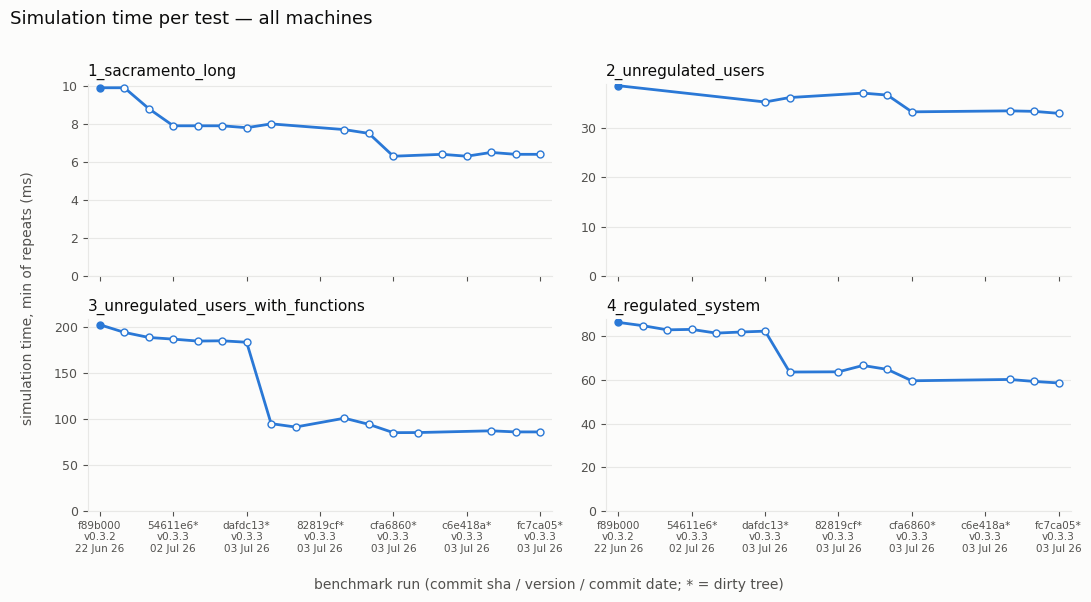

In [2]:
def plot_metric_timeline(metric, suptitle, ylabel):
    """Small multiples: one panel per test, one line per machine, hollow
    markers for dirty-tree runs. Shared by the sim-time and load-time views."""
    n_rows = math.ceil(len(TESTS) / 2)
    fig, axes = plt.subplots(n_rows, 2, figsize=(11, 3 * n_rows), facecolor=SURFACE,
                             sharex=True, squeeze=False)
    for ax in axes.flat[len(TESTS):]:
        ax.set_visible(False)

    for ax, test in zip(axes.flat, TESTS):
        d = df[df.test_name == test]
        style_axes(ax, test)
        for machine in MACHINES:
            dm = d[d.hostname == machine]
            if dm.empty:
                continue
            colour = MACHINE_COLOURS[machine]
            ax.plot(dm.run_id, dm[metric], color=colour, linewidth=2, zorder=2)
            clean = dm[dm.commit_dirty == False]
            dirty = dm[dm.commit_dirty == True]
            ax.plot(clean.run_id, clean[metric], "o", color=colour, markersize=5, zorder=3)
            ax.plot(dirty.run_id, dirty[metric], "o", markerfacecolor=SURFACE,
                    markeredgecolor=colour, markersize=5, zorder=3)
        ax.set_ylim(bottom=0)
        apply_run_axis(ax)

    machine_legend(fig)
    fig.supxlabel("benchmark run (commit sha / version / commit date; * = dirty tree)",
                  fontsize=10, color=INK_2)
    fig.supylabel(ylabel, fontsize=10, color=INK_2)
    fig.suptitle(suptitle, x=0.01, ha="left", fontsize=13, color=INK)
    fig.tight_layout(rect=(0.01, 0, 1, 0.97))
    plt.show()

plot_metric_timeline("sim_min_ms", "Simulation time per test — all machines",
                     "simulation time, min of repeats (ms)")

## Model load time over code history

Same view for the loading phase (INI parse + CSV read + configure). Load is
pure IO + setup — simulation changes should leave it flat, and IO work (e.g.
the 2026-07 CSV fast-path) shows here rather than in the sim chart.

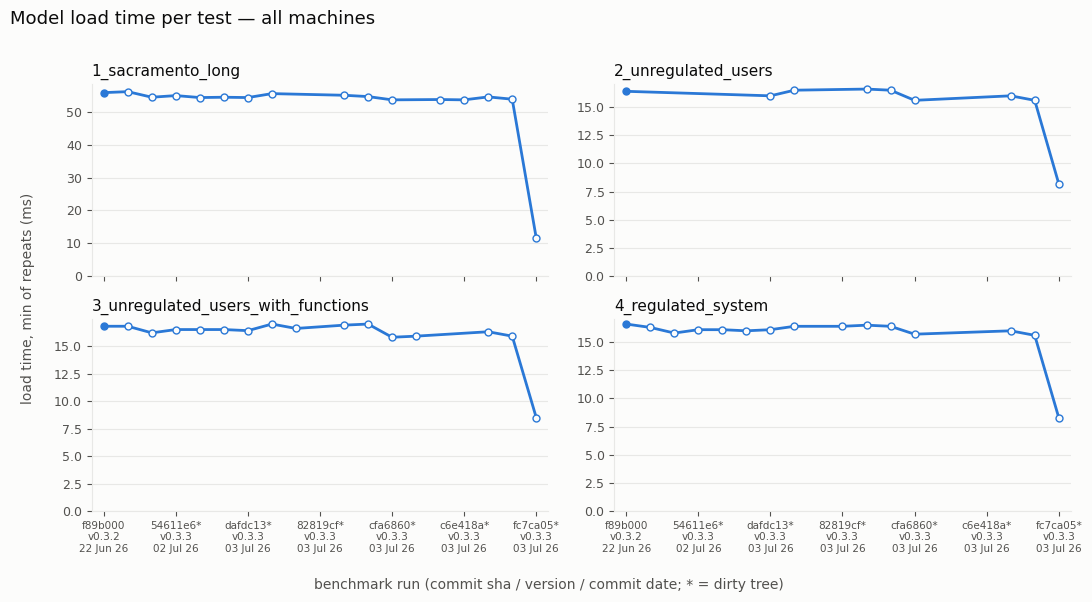

In [3]:
plot_metric_timeline("load_min_ms", "Model load time per test — all machines",
                     "load time, min of repeats (ms)")

## Drift, indexed per machine (each machine's latest = 100)

Same panels, but each machine's line is normalised to **its own** newest
measurement. A point at 150 means "that commit was 50% slower than this
machine's current code". Every machine's line converges on 100 at its own
newest run; a regression shows as the right-hand end climbing above the
dashed line. Machines with a single run appear as a lone dot at 100 —
drift needs history.

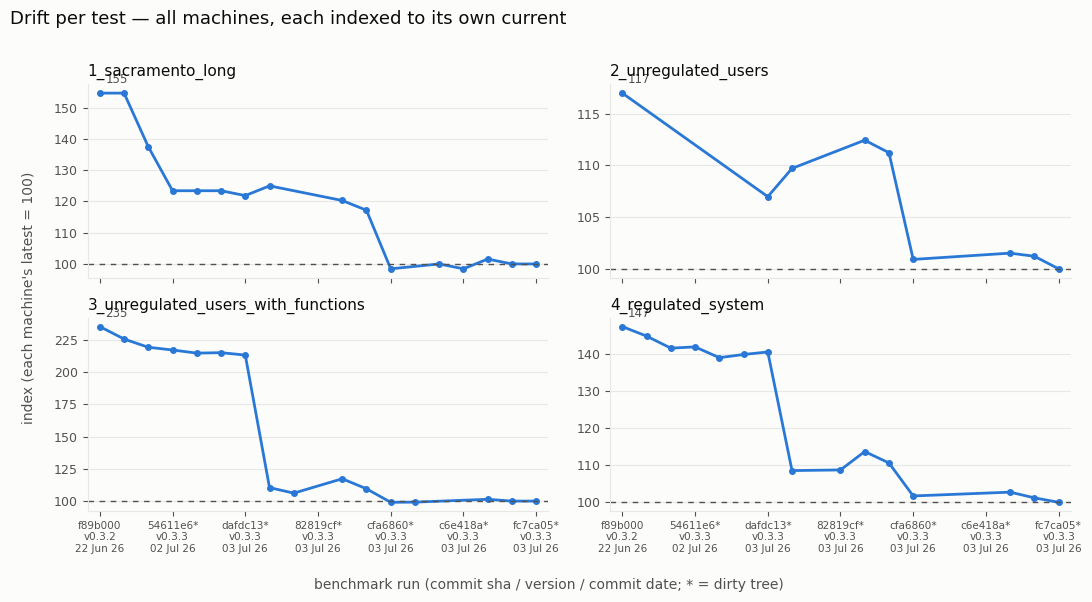

In [4]:
n_rows = math.ceil(len(TESTS) / 2)
fig, axes = plt.subplots(n_rows, 2, figsize=(11, 3 * n_rows), facecolor=SURFACE,
                         sharex=True, squeeze=False)
for ax in axes.flat[len(TESTS):]:
    ax.set_visible(False)

for ax, test in zip(axes.flat, TESTS):
    d = df[df.test_name == test]
    style_axes(ax, test)
    for machine in MACHINES:
        dm = d[d.hostname == machine]
        if dm.empty:
            continue
        # Reference: min across this machine's newest commit (noise-robust)
        newest = dm[dm.commit_date == dm.commit_date.max()]
        indexed = dm.sim_min_ms / newest.sim_min_ms.min() * 100
        colour = MACHINE_COLOURS[machine]
        ax.plot(dm.run_id, indexed, color=colour, linewidth=2,
                marker="o", markersize=4)
        if len(dm) > 1:  # start label only when there is a history to label
            ax.annotate(f"{indexed.iloc[0]:.0f}", (dm.run_id.iloc[0], indexed.iloc[0]),
                        xytext=(4, 7), textcoords="offset points",
                        fontsize=8.5, color=INK_2)
    ax.axhline(100, color=INK_2, linewidth=1, linestyle=(0, (4, 4)))
    apply_run_axis(ax)

machine_legend(fig)
fig.supxlabel("benchmark run (commit sha / version / commit date; * = dirty tree)",
              fontsize=10, color=INK_2)
fig.supylabel("index (each machine's latest = 100)", fontsize=10, color=INK_2)
fig.suptitle("Drift per test — all machines, each indexed to its own current",
             x=0.01, ha="left", fontsize=13, color=INK)
fig.tight_layout(rect=(0.01, 0, 1, 0.97))
plt.show()

## Where the time goes now — per-phase breakdown, latest run per machine

Load / simulate / write-output for each test's latest run on every machine.
Phases wear their own three colours here; the machine is named on the row.

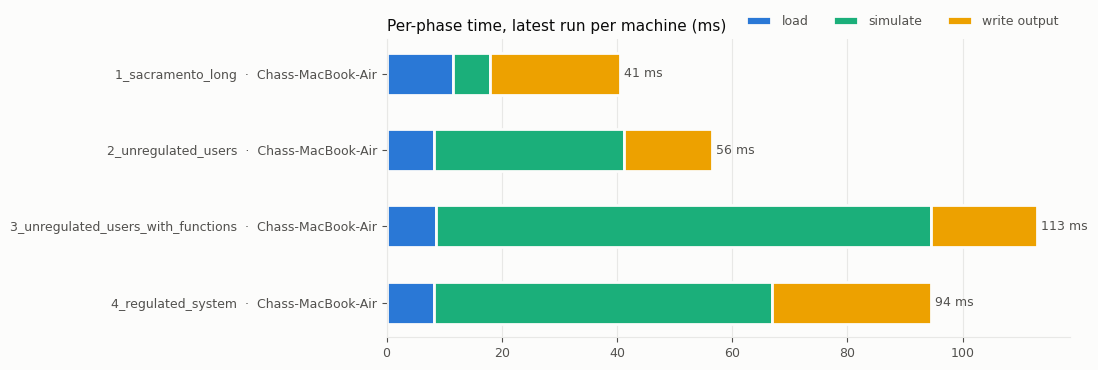

In [5]:
latest = (df.sort_values(["commit_date", "test_date"])
            .groupby(["test_name", "hostname"]).tail(1))
# Row order: tests in discovery order, machines in discovery order within each
rows = [(t, m) for t in TESTS for m in MACHINES
        if not latest[(latest.test_name == t) & (latest.hostname == m)].empty]
latest = latest.set_index(["test_name", "hostname"]).loc[rows]

PHASES = [("load_min_ms", "load", "#2a78d6"),
          ("sim_min_ms", "simulate", "#1baf7a"),
          ("output_min_ms", "write output", "#eda100")]

fig, ax = plt.subplots(figsize=(11, 0.55 * len(rows) + 1.6), facecolor=SURFACE)
style_axes(ax, "Per-phase time, latest run per machine (ms)")
ax.grid(axis="x", color=GRID, linewidth=0.8)
ax.grid(axis="y", visible=False)

y = range(len(rows))
left = pd.Series(0.0, index=latest.index)
for col, label, colour in PHASES:
    ax.barh(y, latest[col], left=left, height=0.55, color=colour, label=label,
            edgecolor=SURFACE, linewidth=2)
    left += latest[col]

for i, total in enumerate(left):
    ax.annotate(f" {total:.0f} ms", (total, i), fontsize=9, color=INK_2, va="center")

labels = [f"{t}  ·  {short_host(m)}" for t, m in rows]
ax.set_yticks(list(y), labels, fontsize=9)
ax.invert_yaxis()
ax.legend(frameon=False, fontsize=9, labelcolor=INK_2, ncols=3,
          loc="lower right", bbox_to_anchor=(1, 1.0))
fig.tight_layout()
plt.show()

## Summary table — oldest vs latest, per test per machine

The table view (also the accessibility fallback for the charts above).

In [6]:
def first_last(group):
    group = group.sort_values(["commit_date", "test_date"])
    first, last = group.iloc[0], group.iloc[-1]
    return pd.Series({
        "runs": len(group),
        "oldest commit": str(first.commit_date.date()),
        "sim oldest (ms)": first.sim_min_ms,
        "sim latest (ms)": last.sim_min_ms,
        "sim change": f"{(last.sim_min_ms / first.sim_min_ms - 1) * 100:+.0f}%",
        "load latest (ms)": last.load_min_ms,
        "output latest (ms)": last.output_min_ms,
        "latest commit": last.commit_sha,
    })

(df.assign(machine=df.hostname.map(short_host))
   .groupby(["test_name", "machine"])
   .apply(first_last, include_groups=False))

,,runs,oldest commit,sim oldest (ms),sim latest (ms),sim change,load latest (ms),output latest (ms),latest commit
test_name,machine,,,,,,,,
1_sacramento_long,Chass-MacBook-Air,16,2026-06-22,9.9,6.4,-35%,11.6,22.6,fc7ca05
2_unregulated_users,Chass-MacBook-Air,9,2026-06-22,38.6,33.0,-15%,8.2,15.3,fc7ca05
3_unregulated_users_with_functions,Chass-MacBook-Air,16,2026-06-22,202.4,86.0,-58%,8.5,18.5,fc7ca05
4_regulated_system,Chass-MacBook-Air,15,2026-06-22,86.3,58.6,-32%,8.3,27.6,fc7ca05
